# Data Challenge : Lynred data

---

In [3]:
import pandas as pd
import numpy as np
import cv2
import glob, os
import matplotlib.pyplot as plt
from skimage import io
from scipy.ndimage import median_filter
from scipy.ndimage import convolve1d

---

## Loading the data

In [4]:
def load_images(folder='train',type='VGA',sequence='sequence_1', dyn='low dyn with columns 1', force_gray=False):
    """
    function that load a folder of images

    args : 
    folder : folder type
    type : type of the frame (HD, VGA, SXGA)
    sequence : sequence_1, sequence_2, sequence_3
    dyn : low dyn with columns 1, low dyn with columns 2, low dyn with columns 3
    force_gray : bool to load in gray (one array)

    return :
    list of the images of the folder
    """
    images = []
    if force_gray == True:
        for image in glob.glob(folder+'/'+type+'/'+sequence+'/'+dyn+'/*'):
            img = io.imread(image, as_gray=True)
            images.append(img)
    else:
        for image in glob.glob(folder+'/'+type+'/'+sequence+'/'+dyn+'/*'):
            img = io.imread(image)
            images.append(img)
    return images

In [5]:
def load_dataset(folder='train'):
    """
    function that load all the data set paths

    return : 
    dict : with every concept containing image paths
    list : with every image path
    """
    types = ['HD', 'SXGA', 'VGA']
    sequences = ['sequence_1', 'sequence_2', 'sequence_3']
    dynamics = [
        'high_dyn',
        'low dyn',
        'low dyn with columns 1',
        'low dyn with columns 2',
        'low dyn with columns 3'
    ]

    dataset_dict = {}
    all_images_list = []

    for t in types:
        dataset_dict[t] = {}
        for seq in sequences:
            dataset_dict[t][seq] = {}
            for dyn in dynamics:

                # Récupère que les fichiers png du dossier
                path_pattern = f"{folder}/{t}/{seq}/{dyn}/*.png"
                
                paths_in_folder = glob.glob(path_pattern)
                
                dataset_dict[t][seq][dyn] = paths_in_folder
                all_images_list.extend(paths_in_folder)

    return dataset_dict, all_images_list

In [6]:
def convert_to_8_img(img_16bit):
    """""
    Convert 16 bits img into 8 bits using percentiles to not be biased by outliers  
    arg : img 
    return : converted img in 8 bits
    """""
    # 1. Utiliser des percentiles pour ignorer les pixels aberrants (très chauds ou très froids)
    # Cela permet de mieux voir les détails de la scène sans être ébloui par les extrêmes
    p2, p98 = np.percentile(img_16bit, (2, 98))
    img_clipped = np.clip(img_16bit, p2, p98)
    
    # 2. Normaliser entre 0 et 255
    img_8bit = ((img_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
    return img_8bit

In [7]:
minus_datetrain = load_images()

## Explore the Dataset

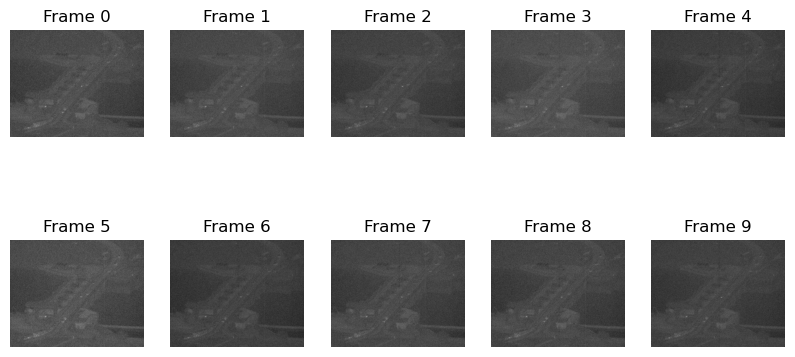

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(0,2,1):
    for j in range(0,5,1):
        index_image = i * 5 + j 
        axes[i, j].imshow(minus_datetrain[index_image], cmap='gray')
        axes[i, j].set_title(f'Frame {index_image}')
        axes[i, j].axis('off')

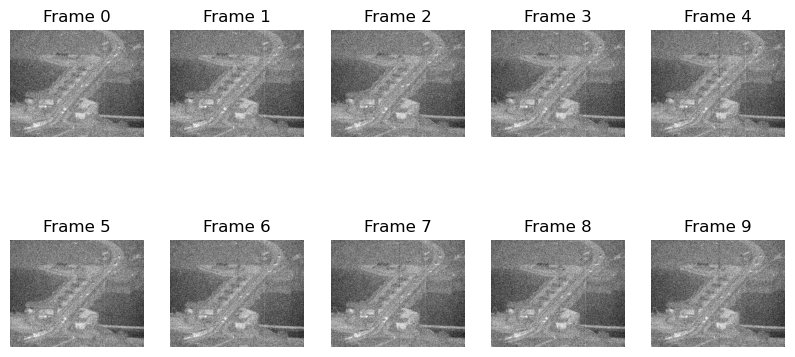

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(0,2,1):
    for j in range(0,5,1):
        index_image = i * 5 + j 
        axes[i, j].imshow(convert_to_8_img(minus_datetrain[index_image]), cmap='gray')
        axes[i, j].set_title(f'Frame {index_image}')
        axes[i, j].axis('off')

---

## Try to detect columns

In [10]:
def detect_partial_columns(img_16bit, num_bands=8, window_size=25, sigma=3.5):
    """
    Découpe l'image en `num_bands` horizontales et cherche les colonnes 
    défectueuses dans chaque bande de manière indépendante.
    """
    hauteur, largeur = img_16bit.shape
    band_height = hauteur // num_bands
    
    # On va stocker les défauts sous forme de tuples : (colonne_X, Y_début, Y_fin)
    partial_defects = [] 
    
    for b in range(num_bands):
        # Définir les limites Y de la bande actuelle
        y_start = b * band_height
        # La dernière bande prend tous les pixels restants
        y_stop = hauteur if b == num_bands - 1 else (b + 1) * band_height
        
        # Isoler la portion de l'image (le "chunk")
        band_img = img_16bit[y_start:y_stop, :]
        
        # --- Appliquer notre méthode locale (MAIS UNIQUEMENT SUR CETTE BANDE) ---
        band_profile = np.mean(band_img, axis=0)
        local_background = median_filter(band_profile, size=window_size)
        residual = band_profile - local_background
        
        # Seuillage
        std_residual = np.std(residual)
        threshold = sigma * std_residual
        
        # Détection
        bad_cols = np.where(np.abs(residual) > threshold)[0]
        
        # Enregistrer les coordonnées
        for col in bad_cols:
            partial_defects.append((col, y_start, y_stop))
            
    return partial_defects

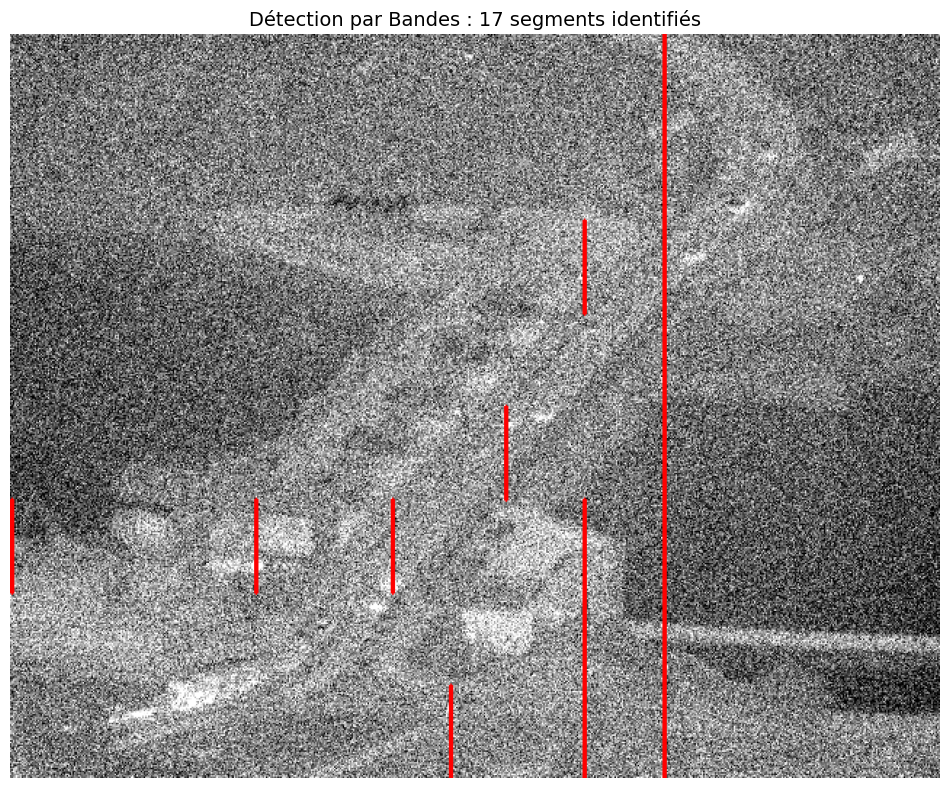

In [11]:
def visualize_partial_columns(img_16bit, partial_defects):
    """
    Dessine les segments rouges uniquement là où le défaut a été trouvé.
    """
    img_8bit = convert_to_8_img(img_16bit)
    img_color = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2RGB)
    
    for col, y_start, y_stop in partial_defects:
        cv2.line(img_color, (col, y_start), (col, y_stop), (255, 0, 0), 2)
        
    plt.figure(figsize=(12, 10))
    plt.imshow(img_color)
    plt.title(f"Détection par Bandes : {len(partial_defects)} segments identifiés", fontsize=14)
    plt.axis('off')
    plt.show()

defauts_partiels = detect_partial_columns(minus_datetrain[0], num_bands=8, sigma=3.5)
visualize_partial_columns(minus_datetrain[0], defauts_partiels)

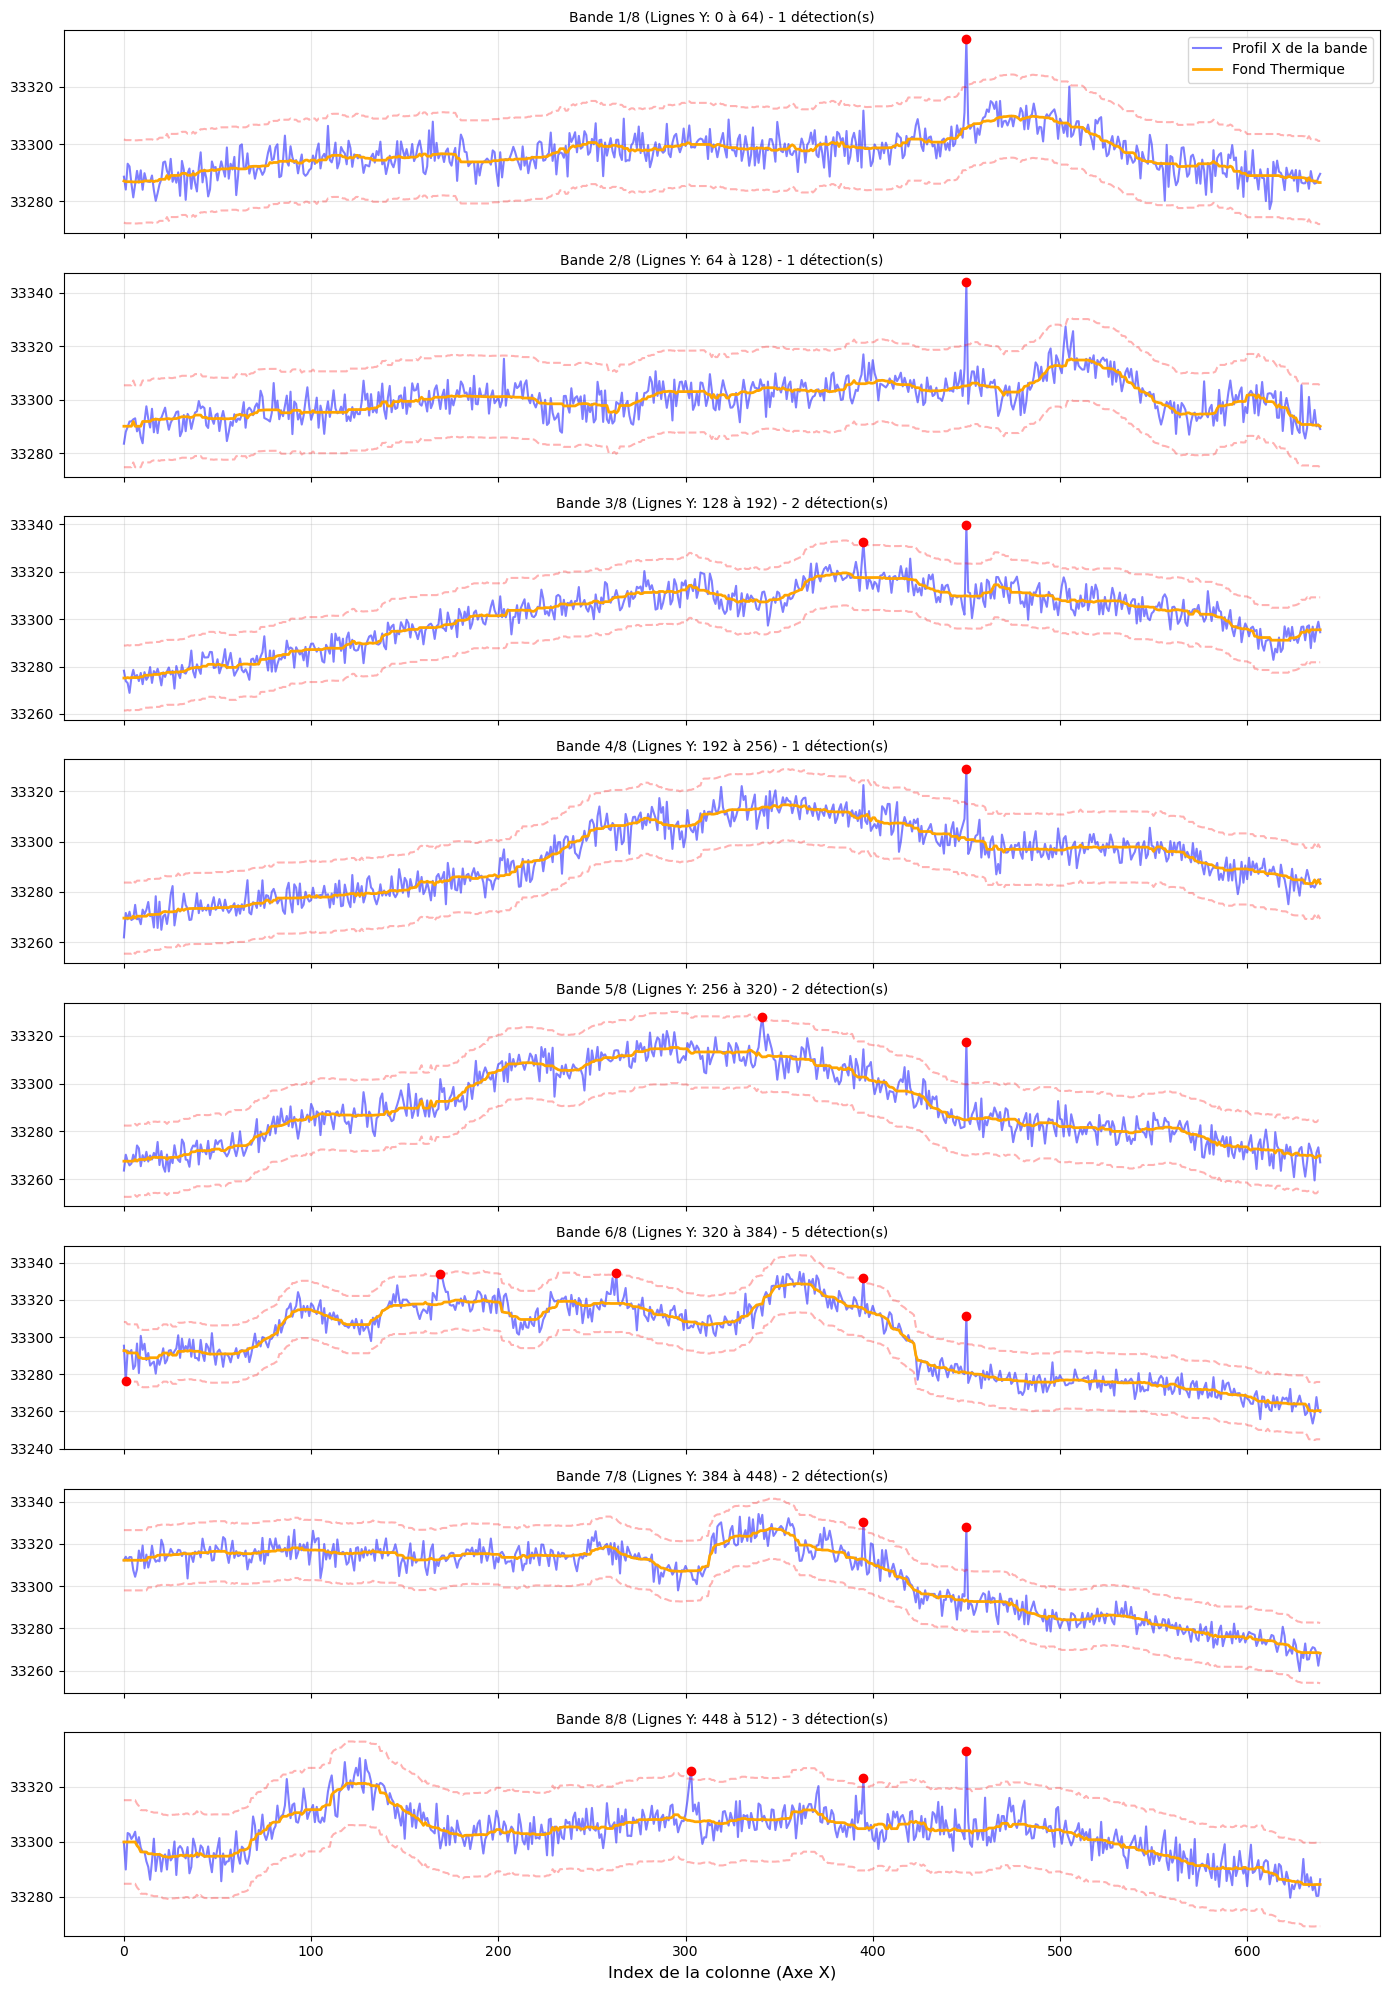

In [12]:
def plot_all_band_profiles(img_16bit, num_bands=8, window_size=25, sigma=4):
    """
    Affiche le graphique de détection locale pour chaque bande horizontale de l'image.
    Les graphiques sont empilés pour pouvoir aligner visuellement les colonnes.
    """
    hauteur, largeur = img_16bit.shape
    band_height = hauteur // num_bands
    
    fig, axes = plt.subplots(num_bands, 1, figsize=(14, 2.5 * num_bands), sharex=True)
    
    for b in range(num_bands):
        y_start = b * band_height
        y_stop = hauteur if b == num_bands - 1 else (b + 1) * band_height
        
        band_img = img_16bit[y_start:y_stop, :]
        band_profile = np.mean(band_img, axis=0)
        
        local_background = median_filter(band_profile, size=window_size)
        residual = band_profile - local_background
        std_residual = np.std(residual)
        threshold = sigma * std_residual
        
        bad_cols = np.where(np.abs(residual) > threshold)[0]

        ax = axes[b]
        ax.plot(band_profile, color='blue', alpha=0.5, label='Profil X de la bande')
        ax.plot(local_background, color='orange', linewidth=2, label='Fond Thermique')
        
        # Tracé de l'enveloppe de tolérance
        ax.plot(local_background + threshold, color='red', linestyle='--', alpha=0.3)
        ax.plot(local_background - threshold, color='red', linestyle='--', alpha=0.3)
        
        if len(bad_cols) > 0:
            ax.scatter(bad_cols, band_profile[bad_cols], color='red', zorder=5)
            
        ax.set_title(f"Bande {b+1}/{num_bands} (Lignes Y: {y_start} à {y_stop}) - {len(bad_cols)} détection(s)", fontsize=10)
        ax.grid(True, alpha=0.3)

        if b == 0:
            ax.legend(loc='upper right')
            
    plt.xlabel("Index de la colonne (Axe X)", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_all_band_profiles(minus_datetrain[0], num_bands=8, window_size=25, sigma=3.5)

## Testons le Constant False Alarm Rate (CFAR)

Fir p_fa=0.001 et N=20 alpha : 8.25
Defect Colums detected : []


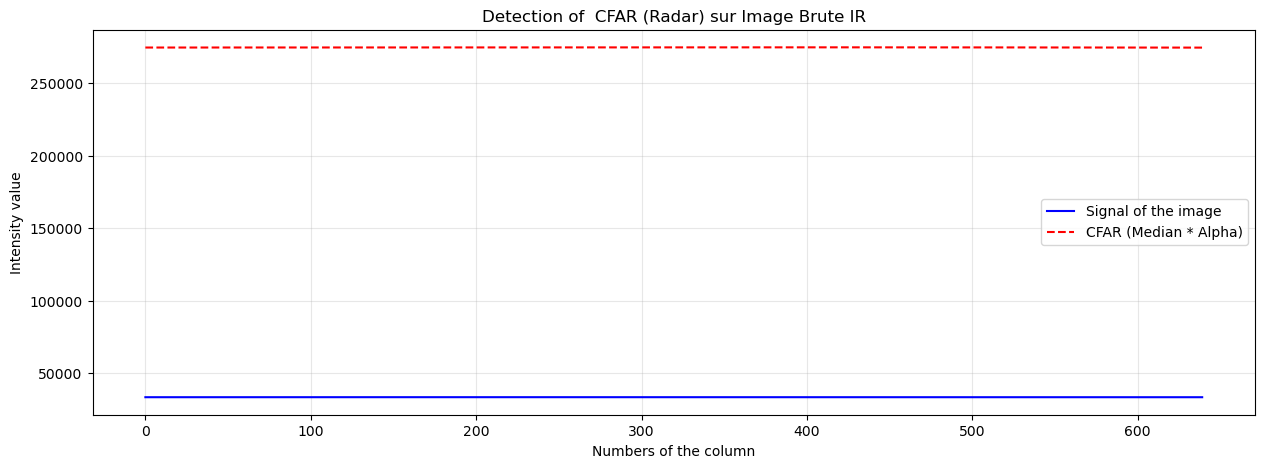

In [13]:
def CFAR_1D(image, len_train=10, len_guard=3, p_fa=0.001):
    """
    Using CFAR-1D on image
    """
    defects = []
    hauteur, largeur = image.shape

    N = len_train * 2 # Numbers of trainingcells 
    alpha = N * (p_fa**(-1/N) - 1)
    
    print(f"Fir p_fa={p_fa} et N={N} alpha : {alpha:.2f}")

    profil = np.mean(image, axis=0) # 
    seuils_calcules = np.zeros(largeur)

    # For each columns of the image we will calculate is CFAR
    for x in range(largeur):

        # To avoid problems at the boundaries
        debut_gauche = max(0, x - len_guard - len_train)
        fin_gauche = max(0, x - len_guard)
        debut_droite = min(largeur, x + len_guard + 1)
        fin_droite = min(largeur, x + len_guard + 1 + len_train)

        # Extraction des cellules d'apprentissage
        train_cells = np.concatenate((profil[debut_gauche:fin_gauche], 
                                      profil[debut_droite:fin_droite]))

        if len(train_cells) > 0:
            # Utilisation de la Médiane (OS-CFAR) ou Moyenne (CA-CFAR)
            bg_val = np.median(train_cells) 
            
            # --- LA MÉTHODE MULTIPLICATIVE QUE VOUS VOULEZ TESTER ---
            threshold = bg_val * alpha
            seuils_calcules[x] = threshold
            
            # Test de la colonne
            if profil[x] > threshold:
                defects.append(x)
        else:
            seuils_calcules[x] = np.inf

    return defects, profil, seuils_calcules

# ==========================================
# --- Test dans votre notebook ---
# ==========================================

# On teste avec p_fa=0.001 (1 fausse alarme pour 1000 pixels)
colonnes_hs, profil_1d, seuils = CFAR_1D(minus_datetrain[0], len_train=10, len_guard=3, p_fa=0.001)

print(f"Defect Colums detected : {colonnes_hs}")

# Affichage visuel
plt.figure(figsize=(15, 5))
plt.plot(profil_1d, label="Signal of the image", color='blue')
plt.plot(seuils, color='red', linestyle='--', label="CFAR (Median * Alpha)")

if len(colonnes_hs) > 0:
    plt.scatter(colonnes_hs, profil_1d[colonnes_hs], color='red', zorder=5)

plt.legend()
plt.title("Detection of  CFAR (Radar) sur Image Brute IR")
plt.xlabel("Numbers of the column")
plt.ylabel("Intensity value")
plt.grid(True, alpha=0.3)
plt.show()

> On observe une grosse erreur donc la méthode ne marche pas (à comprendre pq plus tard)

In [14]:
guard_len = 3
train_len = 5

cfar_kernel = np.ones((1 + 2*guard_len + 2*train_len), dtype=float) / (2*train_len)
cfar_kernel[train_len: train_len + (2*guard_len) + 1] = 0.

gaurd_cells = np.zeros_like(cfar_kernel)
gaurd_cells[train_len: train_len + (2*guard_len) + 1] = cfar_kernel[0]
gaurd_cells[len(gaurd_cells)//2] = 0.

cut = np.zeros_like(cfar_kernel)
cut[len(gaurd_cells)//2] = cfar_kernel[0]

print(cfar_kernel)
print(50*'-')
print(cut)

[0.1 0.1 0.1 0.1 0.1 0.  0.  0.  0.  0.  0.  0.  0.1 0.1 0.1 0.1 0.1]
--------------------------------------------------
[0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.  0. ]


Voici mon Kernel et le mask pour me déplacer dans l'image. Il va falloir s'occuper des coins.

In [19]:
def CFAR_convolved_1D(image, len_train=10, len_guard=3, p_fa=0.001):
    """
    Using CFAR with a kernel dectect defects columns and meand or median of each columns
    """
    defects = [] # Liste de tuples des coordonnées des pixels defectueux
    hauteur, largeur = image.shape # On prend les tailles des images

    N = 2*len_train # Calcul de la taille des cellules d'entraînement totaux
    alpha = N * (p_fa**(-1/N) - 1) # alpha

    # Calcul du kernel en fonction du nombre de cellules gardiennes et d'entraînements
    cfar_kernel = np.ones((1 + 2*len_guard + N), dtype=float) / N
    cfar_kernel[len_train: len_train + (2*len_guard) + 1] = 0.

    profil_1d = np.median(image, axis=0)
    noise_level = convolve1d(profil_1d, cfar_kernel, mode='reflect')
    threshold = noise_level + np.log(alpha)
    for x in range(largeur):
            if profil_1d[x] > threshold[x]:
                defects.append(x) # On ajoute juste 'x' à la liste
    return defects

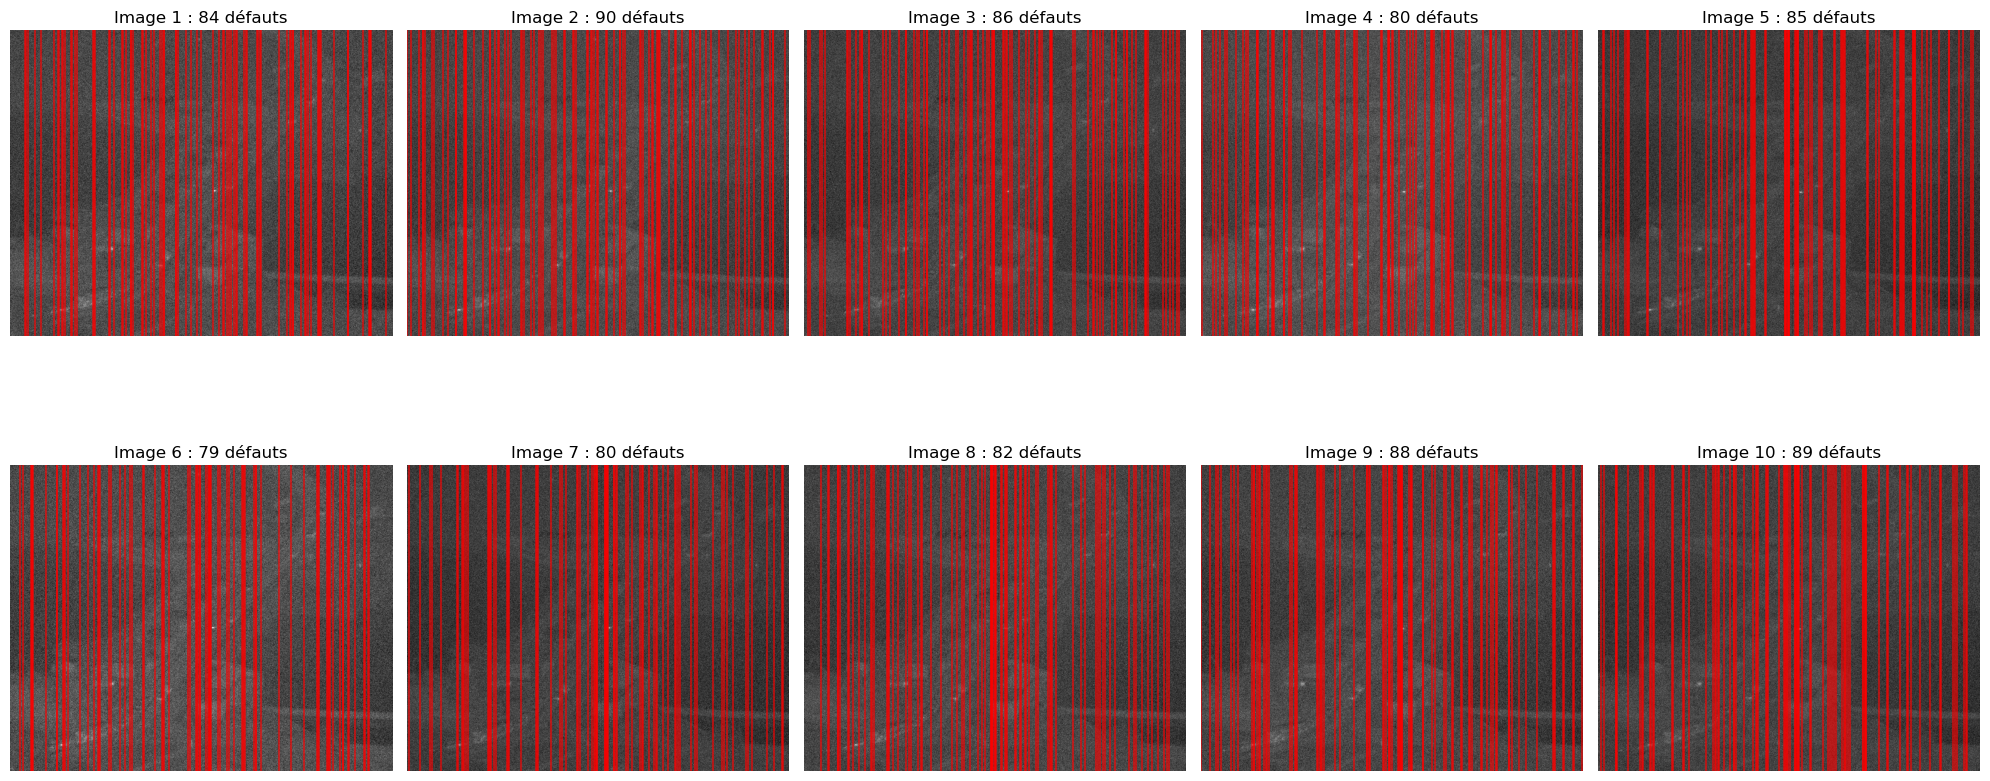

In [21]:
plt.figure(figsize=(20, 10))

# On parcourt les 10 premières images (attention au nom de votre variable, c'est minus_datetrain dans votre code)
for i, img in enumerate(minus_datetrain[:10]):
    
    # Sécurité : si l'image a 3 dimensions (couleur RGB), on ne garde qu'un canal (ou on la passe en gris)
    # pour que l'algorithme fonctionne correctement sur une matrice 2D
    img_gray = img[:,:,0] if len(img.shape) == 3 else img
    
    # Application de l'algorithme CFAR (on force en float pour éviter les erreurs de calcul)
    colonnes_detectees = CFAR_convolved_1D(img_gray.astype(float), len_train=10, len_guard=3, p_fa=0.001)
    
    # Création du sous-graphique (2 lignes, 5 colonnes)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray') # On affiche l'image
    
    # Superposition des lignes rouges
    for col in colonnes_detectees:
        
        # --- LA CORRECTION EST ICI ---
        # Si 'col' est un tuple (x, y) ou un array, on ne garde que la première valeur (le x)
        if isinstance(col, (list, tuple, np.ndarray)):
            x_val = col[0] 
        else:
            x_val = col
        
        # On force x_val en entier (int) pour rassurer matplotlib
        plt.axvline(x=int(x_val), color='red', linestyle='-', alpha=0.6, linewidth=1.5)
        
    plt.title(f"Image {i+1} : {len(colonnes_detectees)} défauts")
    plt.axis('off') # On cache les axes (x,y) pour rendre ça plus propre

plt.tight_layout()
plt.show()

---
## Trouvons un algo moins coûteux et plus précis

---

## Différence entre les images (dérivé temporelle)